## Setup

In [1]:
# notebooks/03_exploratory_visualizations.ipynb

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from src.data_loader import DataLoader


## Load Data & Configuration

In [2]:
PROJECT_ROOT = Path.cwd().parent
figures_dir = PROJECT_ROOT / 'reports' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

# Load data
loader = DataLoader()
df = pd.read_csv(loader.processed_dir / "cleaned_data.csv")

# steamId is an identifier, not a real variable — exclude from every plot below.
ID_COLUMNS = ['steamId']
# publisherClass (Indie/AA/AAA -- the lone 'Hobbyist' row was collapsed
# into Indie during cleaning, see notebook 01) is the only genuinely
# low-cardinality grouping variable in this dataset. 'name', 'publishers',
# and 'developers' are high-cardinality text (hundreds/thousands of unique
# values) and would make boxplots/scatter colors unreadable if auto-selected.
CATEGORY_COL = 'publisherClass'


def numeric_columns(df: pd.DataFrame) -> list:
    cols = df.select_dtypes(include=['int64', 'float64']).columns
    return list(cols.difference(ID_COLUMNS))


# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


## 1. Distribution Plots

In [3]:
def create_distribution_plots(df: pd.DataFrame):
    """Create histogram + KDE plots for numeric columns (excluding IDs)."""
    numeric_cols = numeric_columns(df)

    n_cols = 3
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(numeric_cols):
        data = df[col].dropna()
        sns.histplot(data, kde=True, ax=axes[idx])
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].axvline(data.mean(), color='red', linestyle='--',
                           label=f'Mean: {data.mean():.2f}')
        axes[idx].axvline(data.median(), color='green', linestyle='--',
                           label=f'Median: {data.median():.2f}')
        axes[idx].legend()

    for idx in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.savefig(figures_dir / 'distribution_plots.png', dpi=300, bbox_inches='tight')
    plt.show()


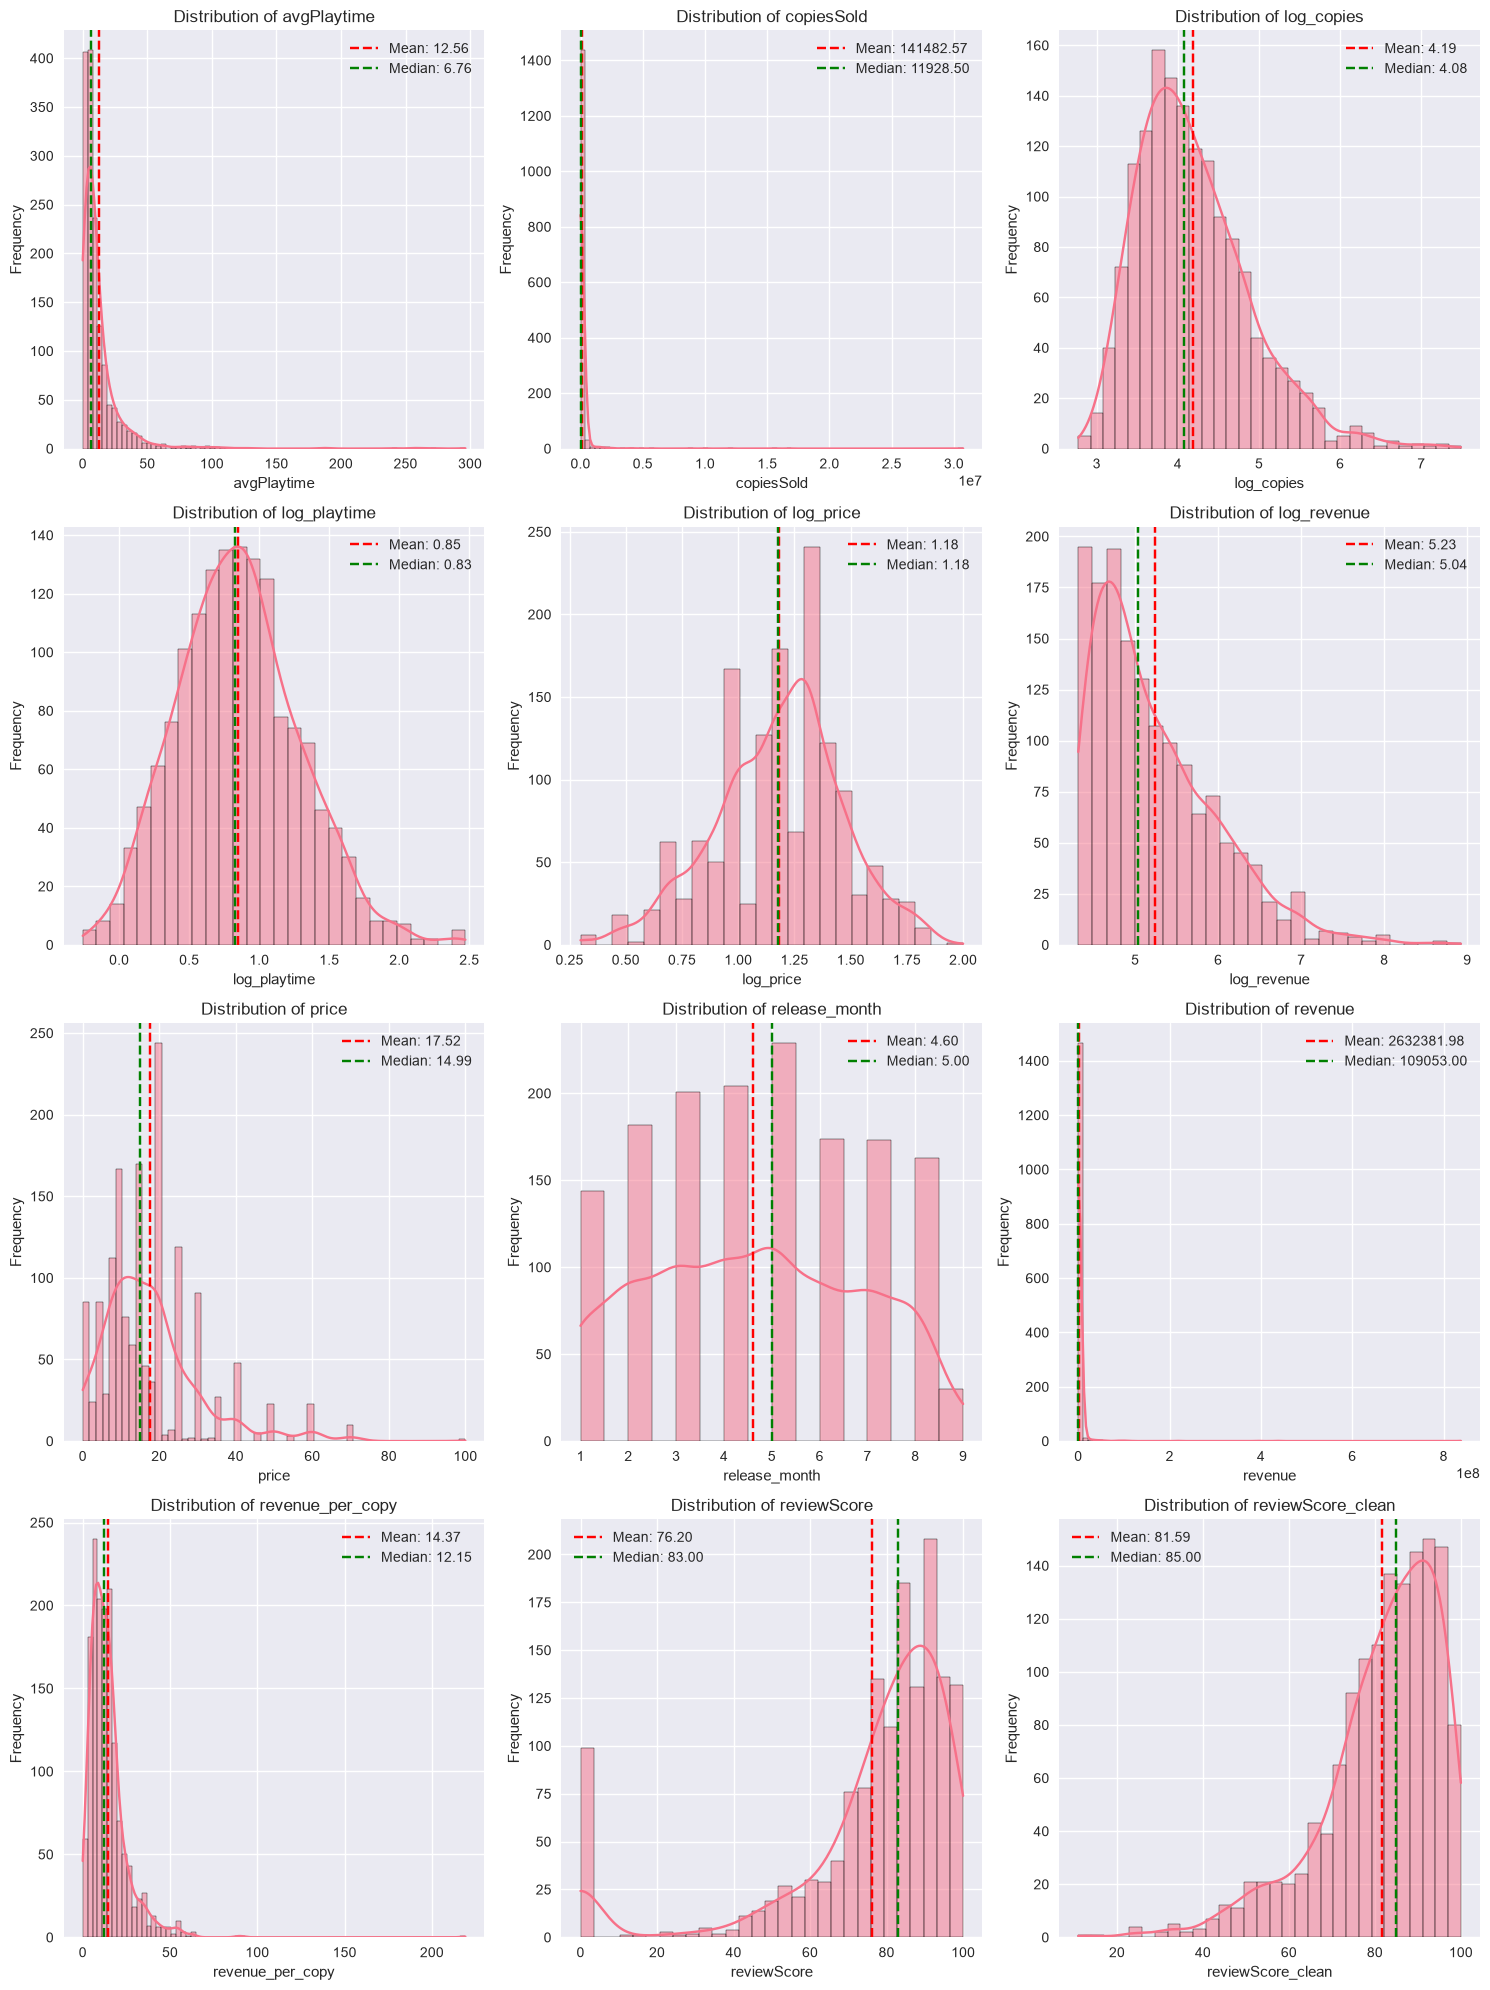

In [4]:
create_distribution_plots(df)


## 2. Box Plots by `publisherClass`

In [5]:
def create_boxplots(df: pd.DataFrame):
    """Create boxplots of each numeric column grouped by publisherClass."""
    numeric_cols = numeric_columns(df)

    if CATEGORY_COL not in df.columns:
        # Fallback: no meaningful grouping variable available
        fig, axes = plt.subplots(1, min(4, len(numeric_cols)), figsize=(15, 5))
        if len(numeric_cols) == 1:
            axes = [axes]
        for idx, col in enumerate(numeric_cols[:4]):
            sns.violinplot(data=df[col].dropna(), ax=axes[idx])
            axes[idx].set_title(f'Distribution of {col}')
            axes[idx].set_ylabel(col)
        plt.tight_layout()
        plt.savefig(figures_dir / 'violin_plots.png', dpi=300, bbox_inches='tight')
        plt.show()
        return

    n_cols = 3
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(numeric_cols):
        sns.boxplot(data=df, x=CATEGORY_COL, y=col, ax=axes[idx])
        axes[idx].set_title(f'{col} by {CATEGORY_COL}')
        axes[idx].set_xlabel(CATEGORY_COL)
        axes[idx].set_ylabel(col)
        axes[idx].tick_params(axis='x', rotation=45)

    for idx in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.savefig(figures_dir / 'boxplots.png', dpi=300, bbox_inches='tight')
    plt.show()


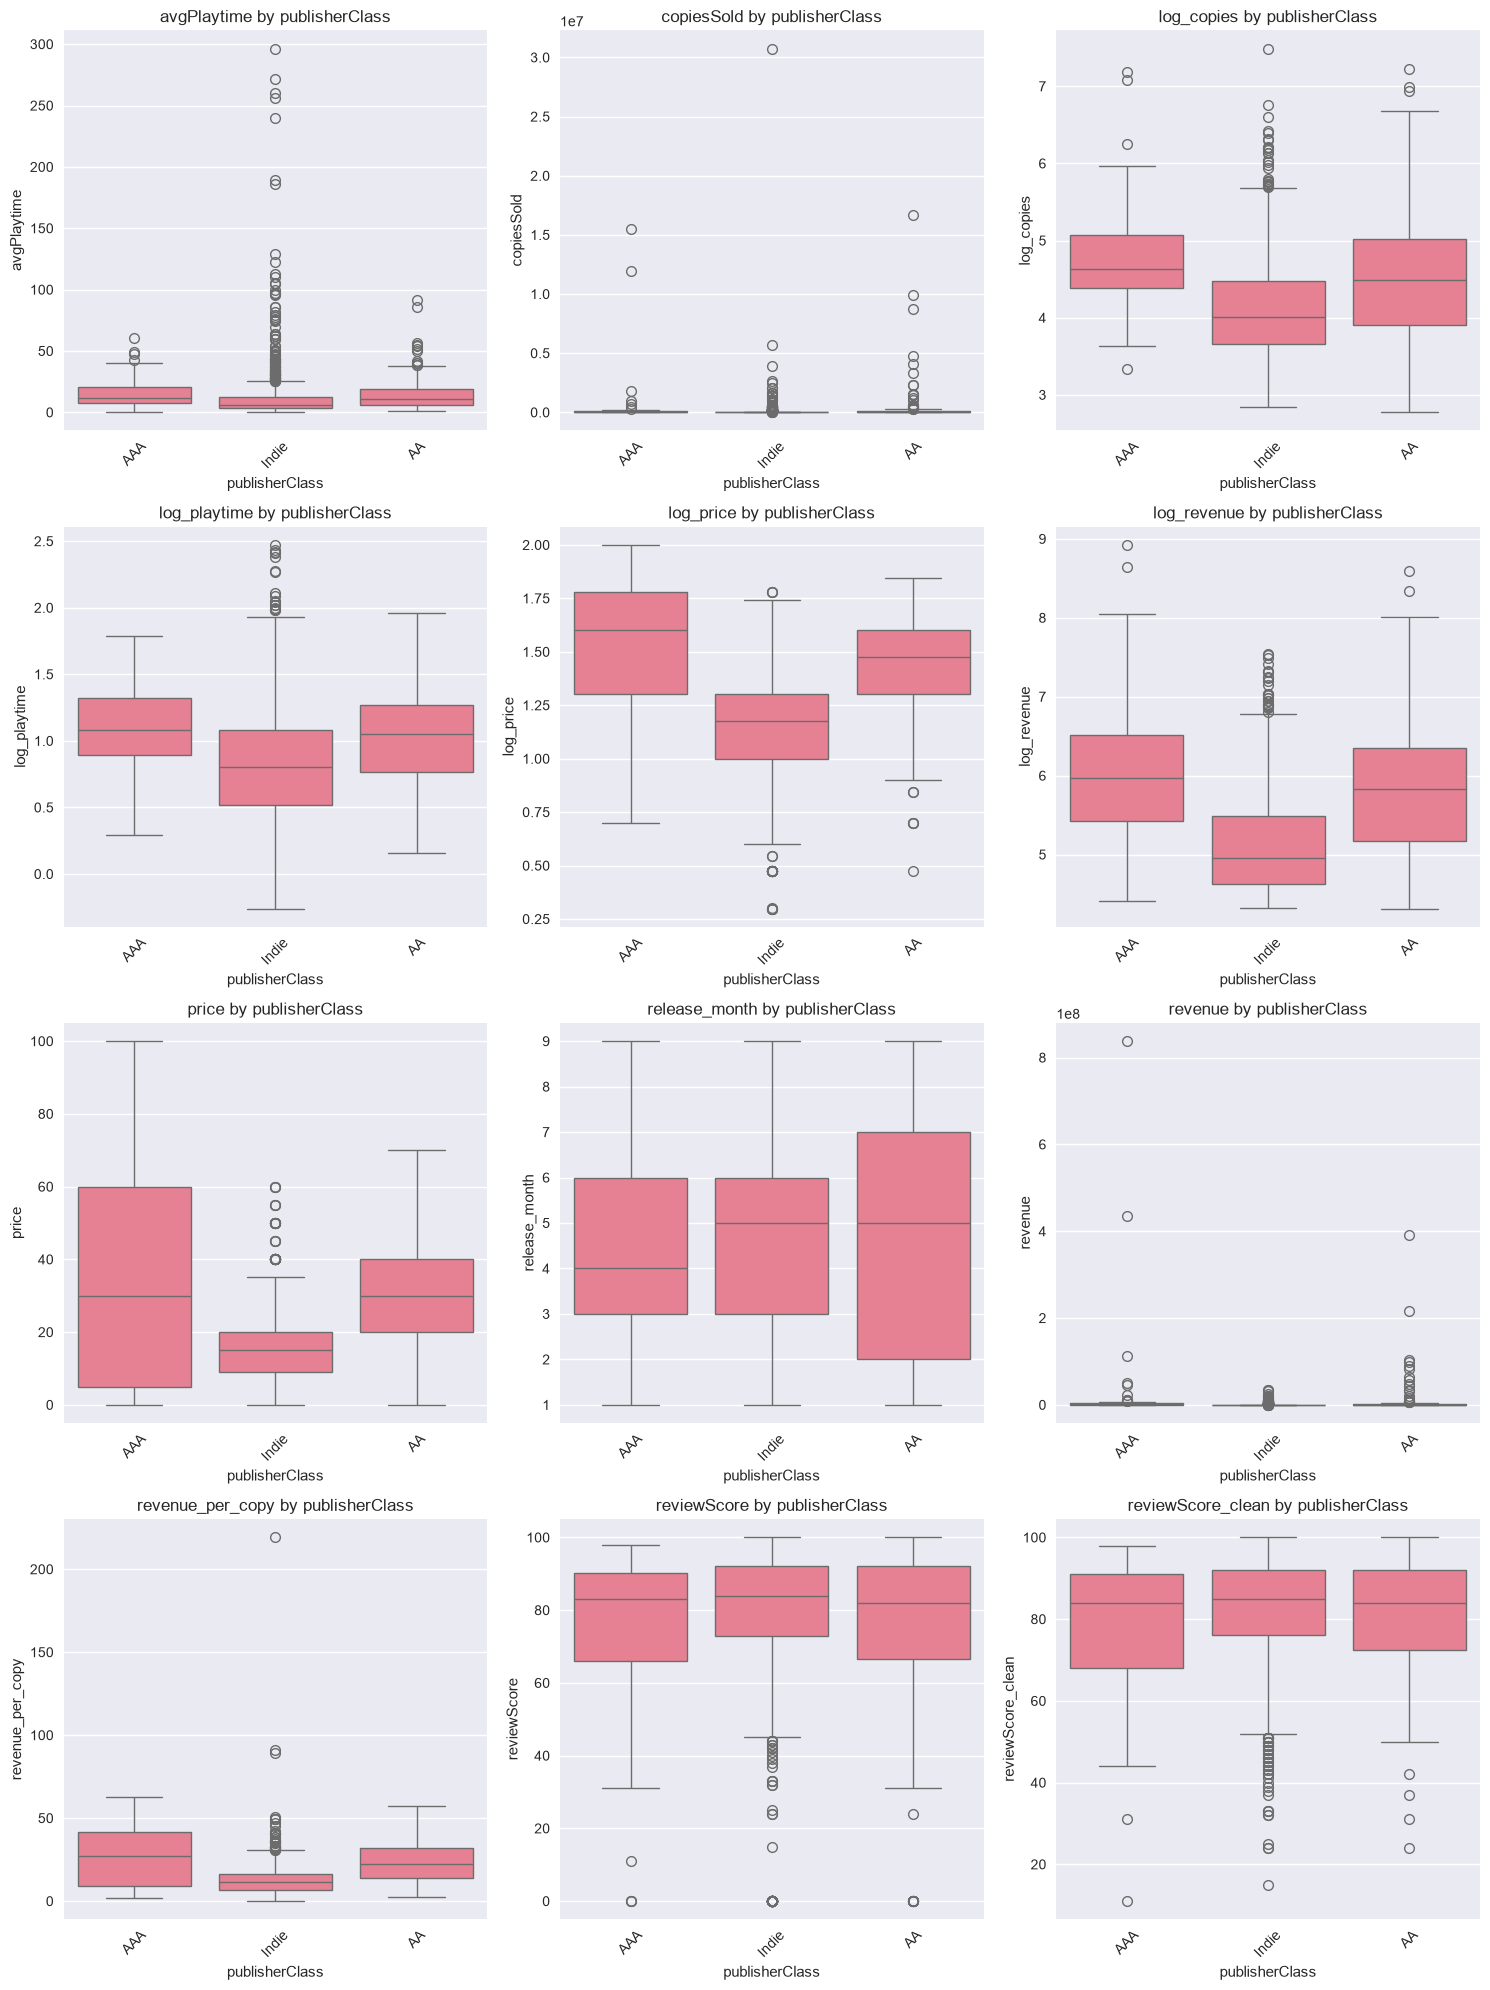

In [6]:
create_boxplots(df)


## 3. Correlation Heatmap

In [7]:
def create_correlation_heatmap(df: pd.DataFrame):
    """Create correlation heatmap (excluding ID columns)."""
    numeric_cols = numeric_columns(df)
    corr = df[numeric_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, square=True, linewidths=0.5, ax=ax)
    ax.set_title('Correlation Heatmap')
    plt.tight_layout()
    plt.savefig(figures_dir / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()


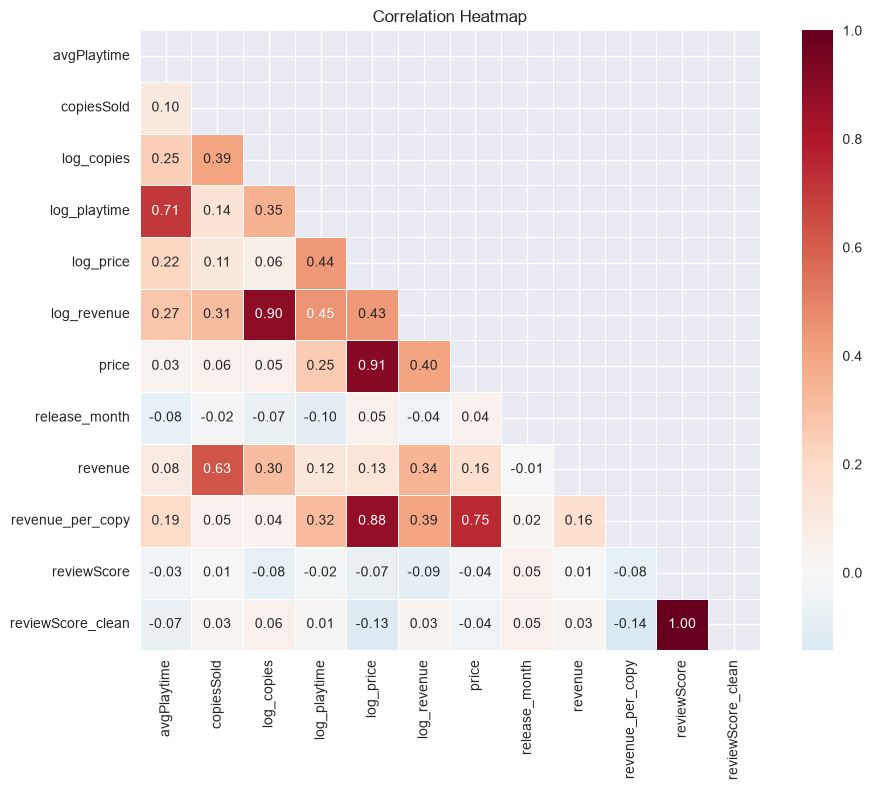

In [8]:
create_correlation_heatmap(df)


## 4. Interactive Plots (Plotly)

**3D scatter (`reports/figures/3d_scatter.html`)** 

- Heavy-tailed variables (copies sold, revenue, playtime, revenue/copy) are drawn on **log axes with real-unit tick labels** (`1K … 10M`, `$1 … $100`); on linear axes almost all 1,500 games collapse into one corner.
- Default axes are three genuinely different variables: **price × copies sold × review score**. Revenue = price × copies, so it is offered as the *colour* instead of an axis. The function asserts the default axes are not near-redundant (the previous version plotted `copiesSold` against `log_copies`, i.e. the same information twice).
- Colour by `publisherClass` (clickable legend) or by log-revenue; dropdowns swap any axis; hover shows the game name and every raw metric.
- Uses `reviewScore_clean` (raw `reviewScore` encodes "no reviews" as 0, which would create a fake cluster); games without reviews are omitted from views that use that axis.

In [9]:
def create_interactive_plots(df: pd.DataFrame):

    numeric_cols = numeric_columns(df)
    color_col = CATEGORY_COL if CATEGORY_COL in df.columns else None

    if len(numeric_cols) <= 5:
        fig = px.scatter_matrix(
            df, dimensions=numeric_cols, color=color_col, title="Scatter Matrix"
        )
        fig.write_html(str(figures_dir / 'scatter_matrix.html'))

    create_3d_scatter(df)

    if 1 < len(numeric_cols) <= 4:
        fig = px.scatter_matrix(
            df, dimensions=numeric_cols[:4], color=color_col, title="Interactive Pair Plot"
        )
        fig.write_html(str(figures_dir / 'pair_plot.html'))


# ---------------------------------------------------------------------------
# 3D scatter: variable catalogue
# ---------------------------------------------------------------------------
# Every variable is plotted on the scale the analysis actually uses: the
# heavy-tailed ones (copiesSold, revenue, playtime, revenue/copy) on log10
# axes, price on log10(1+x) so free games (price = 0) stay visible. Tick
# labels are written in REAL units ("100K", "$1M"), so the plot is readable
# without mentally un-logging anything.
#   col       : column in the cleaned data (raw units)
#   transform : 'log10' | 'log1p10' (log10(1+x)) | 'linear'
#   ticks     : (values, labels) shown on the axis, in raw units
_K = lambda v: (f"{v/1e9:g}B" if v >= 1e9 else f"{v/1e6:g}M" if v >= 1e6
                else f"{v/1e3:g}K" if v >= 1e3 else f"{v:g}")

SCATTER3D_VARS = {
    'Copies sold':        dict(col='copiesSold', transform='log10',
                               ticks=[1e3, 1e4, 1e5, 1e6, 1e7],
                               fmt=lambda v: _K(v)),
    'Price (USD)':        dict(col='price', transform='log1p10',
                               ticks=[0, 1, 5, 10, 20, 40, 60, 100],
                               fmt=lambda v: f"${v:g}"),
    'Revenue (USD)':      dict(col='revenue', transform='log10',
                               ticks=[1e5, 1e6, 1e7, 1e8, 1e9],
                               fmt=lambda v: f"${_K(v)}"),
    'Avg playtime':       dict(col='avgPlaytime', transform='log1p10',
                               ticks=[0, 1, 3, 10, 30, 100, 300],
                               fmt=lambda v: f"{v:g}"),
    'Review score (%)':   dict(col='reviewScore_clean', transform='linear',
                               ticks=[0, 20, 40, 60, 80, 100],
                               fmt=lambda v: f"{v:g}"),
    'Revenue per copy':   dict(col='revenue_per_copy', transform='log1p10',
                               ticks=[0, 1, 5, 10, 25, 50, 100, 200],
                               fmt=lambda v: f"${v:g}"),
}

CLASS_COLORS = {'Indie': '#4C78A8', 'AA': '#F58518', 'AAA': '#E45756'}  # colour-blind safe


def _to_axis(series: pd.Series, transform: str) -> np.ndarray:
    """Transform raw values to plotting coordinates (NaN stays NaN)."""
    x = series.astype(float).to_numpy()
    if transform == 'log10':
        with np.errstate(divide='ignore', invalid='ignore'):
            x = np.where(x > 0, np.log10(x), np.nan)
        return x
    if transform == 'log1p10':
        return np.log10(1 + x)
    return x


def _axis_layout(label: str, axis: str, df: pd.DataFrame) -> dict:
    """Plotly `scene.<axis>` updates (title + real-unit ticks + range) for one variable."""
    spec = SCATTER3D_VARS[label]
    coords = _to_axis(df[spec['col']], spec['transform'])
    lo, hi = np.nanmin(coords), np.nanmax(coords)
    pad = 0.04 * (hi - lo)
    tv, tt = [], []
    for v in spec['ticks']:
        c = _to_axis(pd.Series([v]), spec['transform'])[0]
        if np.isfinite(c) and lo - pad <= c <= hi + pad:
            tv.append(float(c)); tt.append(spec['fmt'](v))
    suffix = {'log10': ' (log scale)', 'log1p10': ' (log scale)', 'linear': ''}[spec['transform']]
    return {f'scene.{axis}axis.title.text': label + suffix,
            f'scene.{axis}axis.tickvals': tv,
            f'scene.{axis}axis.ticktext': tt,
            f'scene.{axis}axis.range': [float(lo - pad), float(hi + pad)]}


def create_3d_scatter(df: pd.DataFrame,
                      default_axes=('Price (USD)', 'Copies sold', 'Review score (%)'),
                      filename: str = '3d_scatter.html',
                      include_plotlyjs=True):
    """Interactive 3D scatter that is meaningful for this dataset.

    What makes it usable for analysis
    ---------------------------------
    * Axes on log scales with real-unit ticks (the raw variables are extremely
      right-skewed: on linear axes ~all 1,500 points collapse into one corner).
    * Three genuinely different variables by default (price, copies sold,
      review score). Revenue = price x copies, so it is NOT used as an axis by
      default; it is available as the point colour instead.
    * Points coloured by publisherClass with a clickable legend (click = hide,
      double-click = isolate), or by log10(revenue) via the "Colour" menu.
    * Dropdowns to swap any axis for any other variable without re-running.
    * Hover shows the game name and ALL raw metrics, whatever the axes are.
    * Review score uses `reviewScore_clean` (raw `reviewScore` uses 0 as a
      "no reviews" sentinel, which would create a fake cluster at 0);
      games with no reviews are omitted from views that use that axis.
    * Fills the browser window; the Plotly bundle is embedded so the file
      works offline.
    """
    import plotly.graph_objects as go

    d = df.reset_index(drop=True).copy()
    labels = list(SCATTER3D_VARS)
    ax_names = ['x', 'y', 'z']

    # -- guard against the original bug: redundant axes carry no information --
    defaults = [SCATTER3D_VARS[l]['col'] for l in default_axes]
    rho = d[defaults].corr(method='spearman').abs().to_numpy()
    off_diag = rho[~np.eye(3, dtype=bool)]
    assert off_diag.max() < 0.95, (
        f"Default 3D axes are near-redundant (max |Spearman| = {off_diag.max():.2f}); "
        "choose different variables.")
    print("3D scatter default axes |Spearman rho| (should be well below 1):")
    print(pd.DataFrame(rho, index=default_axes, columns=default_axes).round(2))

    coords = {l: _to_axis(d[SCATTER3D_VARS[l]['col']], SCATTER3D_VARS[l]['transform'])
              for l in labels}

    hover = ("<b>%{customdata[0]}</b> (%{customdata[1]})<br>"
             "Copies sold: %{customdata[2]:,.0f}<br>"
             "Price: $%{customdata[3]:.2f}<br>"
             "Revenue: $%{customdata[4]:,.0f}<br>"
             "Revenue / copy: $%{customdata[5]:.2f}<br>"
             "Avg playtime: %{customdata[6]:.1f}<br>"
             "Review score: %{customdata[7]}<extra></extra>")

    def custom(mask):
        sub = d.loc[mask]
        return np.column_stack([
            sub['name'].astype(str), sub['publisherClass'].astype(str),
            sub['copiesSold'], sub['price'], sub['revenue'],
            sub['revenue_per_copy'], sub['avgPlaytime'],
            sub['reviewScore_clean'].map(lambda v: 'n/a' if pd.isna(v) else f"{v:.0f}%")])

    fig = go.Figure()
    classes = [c for c in CLASS_COLORS if c in set(d['publisherClass'])]
    masks = []
    # traces 0..k-1: one per publisher class
    for cls in classes:
        m = (d['publisherClass'] == cls).to_numpy()
        masks.append(m)
        fig.add_trace(go.Scatter3d(
            x=coords[default_axes[0]][m], y=coords[default_axes[1]][m],
            z=coords[default_axes[2]][m], mode='markers',
            name=f"{cls} (n={int(m.sum()):,})",
            marker=dict(size=3.2, color=CLASS_COLORS[cls], opacity=0.75,
                        line=dict(width=0)),
            customdata=custom(m), hovertemplate=hover))
    # trace k: all games, coloured by log10(revenue) (hidden until selected)
    allm = np.ones(len(d), dtype=bool)
    masks.append(allm)
    fig.add_trace(go.Scatter3d(
        x=coords[default_axes[0]], y=coords[default_axes[1]], z=coords[default_axes[2]],
        mode='markers', name='All games', visible=False, showlegend=False,
        marker=dict(size=3.2, opacity=0.8, line=dict(width=0),
                    color=np.log10(d['revenue']), colorscale='Viridis',
                    colorbar=dict(title='Revenue', len=0.55, x=0.94,
                                  tickvals=[5, 6, 7, 8, 9],
                                  ticktext=['$100K', '$1M', '$10M', '$100M', '$1B'])),
        customdata=custom(allm), hovertemplate=hover))

    n_traces = len(masks)
    class_idx = list(range(len(classes)))
    all_idx = [n_traces - 1]

    # -- dropdowns: one per axis, one for colour -----------------------------
    def axis_buttons(pos):
        btns = []
        for lab in labels:
            args_data = {ax_names[pos]: [coords[lab][m] for m in masks]}
            btns.append(dict(label=lab, method='update',
                             args=[args_data, _axis_layout(lab, ax_names[pos], d)]))
        return btns

    menu_common = dict(type='dropdown', direction='down', showactive=True,
                       xanchor='left', yanchor='top', bgcolor='white')
    updatemenus = []
    for pos, (nm, x0) in enumerate(zip('XYZ', (0.00, 0.20, 0.40))):
        updatemenus.append(dict(**menu_common, x=x0, y=1.0,
                                active=labels.index(default_axes[pos]),
                                buttons=axis_buttons(pos), pad=dict(l=38, t=4)))
    vis_class = [i in class_idx for i in range(n_traces)]
    vis_rev = [i in all_idx for i in range(n_traces)]
    updatemenus.append(dict(**menu_common, x=0.60, y=1.0, active=0, pad=dict(l=52, t=4),
        buttons=[dict(label='Publisher class', method='update',
                      args=[{'visible': vis_class}, {'showlegend': True}]),
                 dict(label='Revenue (log)', method='update',
                      args=[{'visible': vis_rev}, {'showlegend': False}])]))

    annotations = [dict(text=t, x=x0, y=1.0, xref='paper', yref='paper',
                        xanchor='left', yanchor='top', showarrow=False, font=dict(size=12))
                   for t, x0 in (('X:', 0.00), ('Y:', 0.20), ('Z:', 0.40), ('Colour:', 0.60))]

    fig.update_layout(
        title=dict(text=("Steam 2024 top-1,500 games: 3D view "
                         f"(n={len(d):,}; log axes, real-unit ticks; games without reviews "
                         "are omitted when Review score is an axis)"),
                   y=0.965, x=0.5, xanchor='center', font=dict(size=15)),
        updatemenus=updatemenus, annotations=annotations,
        legend=dict(title='Publisher class<br><sup>click: hide | double-click: isolate</sup>',
                    itemsizing='constant', x=0.01, y=0.86),
        scene=dict(aspectmode='cube',
                   camera=dict(eye=dict(x=1.6, y=-1.6, z=0.9)),
                   xaxis=dict(backgroundcolor='rgba(0,0,0,0)', gridcolor='rgba(128,128,128,0.35)'),
                   yaxis=dict(backgroundcolor='rgba(0,0,0,0)', gridcolor='rgba(128,128,128,0.35)'),
                   zaxis=dict(backgroundcolor='rgba(0,0,0,0)', gridcolor='rgba(128,128,128,0.35)')),
        margin=dict(l=0, r=0, t=70, b=0), autosize=True, height=780,
        paper_bgcolor='white')
    # initial axis titles / ticks / ranges
    for pos, lab in enumerate(default_axes):
        fig.update_layout({k: v for k, v in _axis_layout(lab, ax_names[pos], d).items()})

    fig.write_html(str(figures_dir / filename), include_plotlyjs=include_plotlyjs,
                   full_html=True, default_width='100%', default_height='92vh',
                   config={'responsive': True, 'displaylogo': False,
                           'modeBarButtonsToRemove': ['orbitRotation', 'tableRotation']})
    return fig


In [10]:
create_interactive_plots(df)


3D scatter default axes |Spearman rho| (should be well below 1):
                  Price (USD)  Copies sold  Review score (%)
Price (USD)              1.00         0.08              0.00
Copies sold              0.08         1.00              0.06
Review score (%)         0.00         0.06              1.00


## 5. Q-Q Plots for Normality Check

In [11]:
def create_qq_plots(df: pd.DataFrame):
    """Create Q-Q plots for numeric columns (excluding IDs)."""
    numeric_cols = numeric_columns(df)

    n_cols = 3
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(numeric_cols):
        data = df[col].dropna()
        stats.probplot(data, dist="norm", plot=axes[idx])
        axes[idx].set_title(f'Q-Q Plot: {col}')
        if len(data) > 3:
            _, p_value = stats.shapiro(data)
            axes[idx].text(0.05, 0.95, f'p = {p_value:.3g}',
                            transform=axes[idx].transAxes, verticalalignment='top',
                            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    for idx in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.savefig(figures_dir / 'qq_plots.png', dpi=300, bbox_inches='tight')
    plt.show()


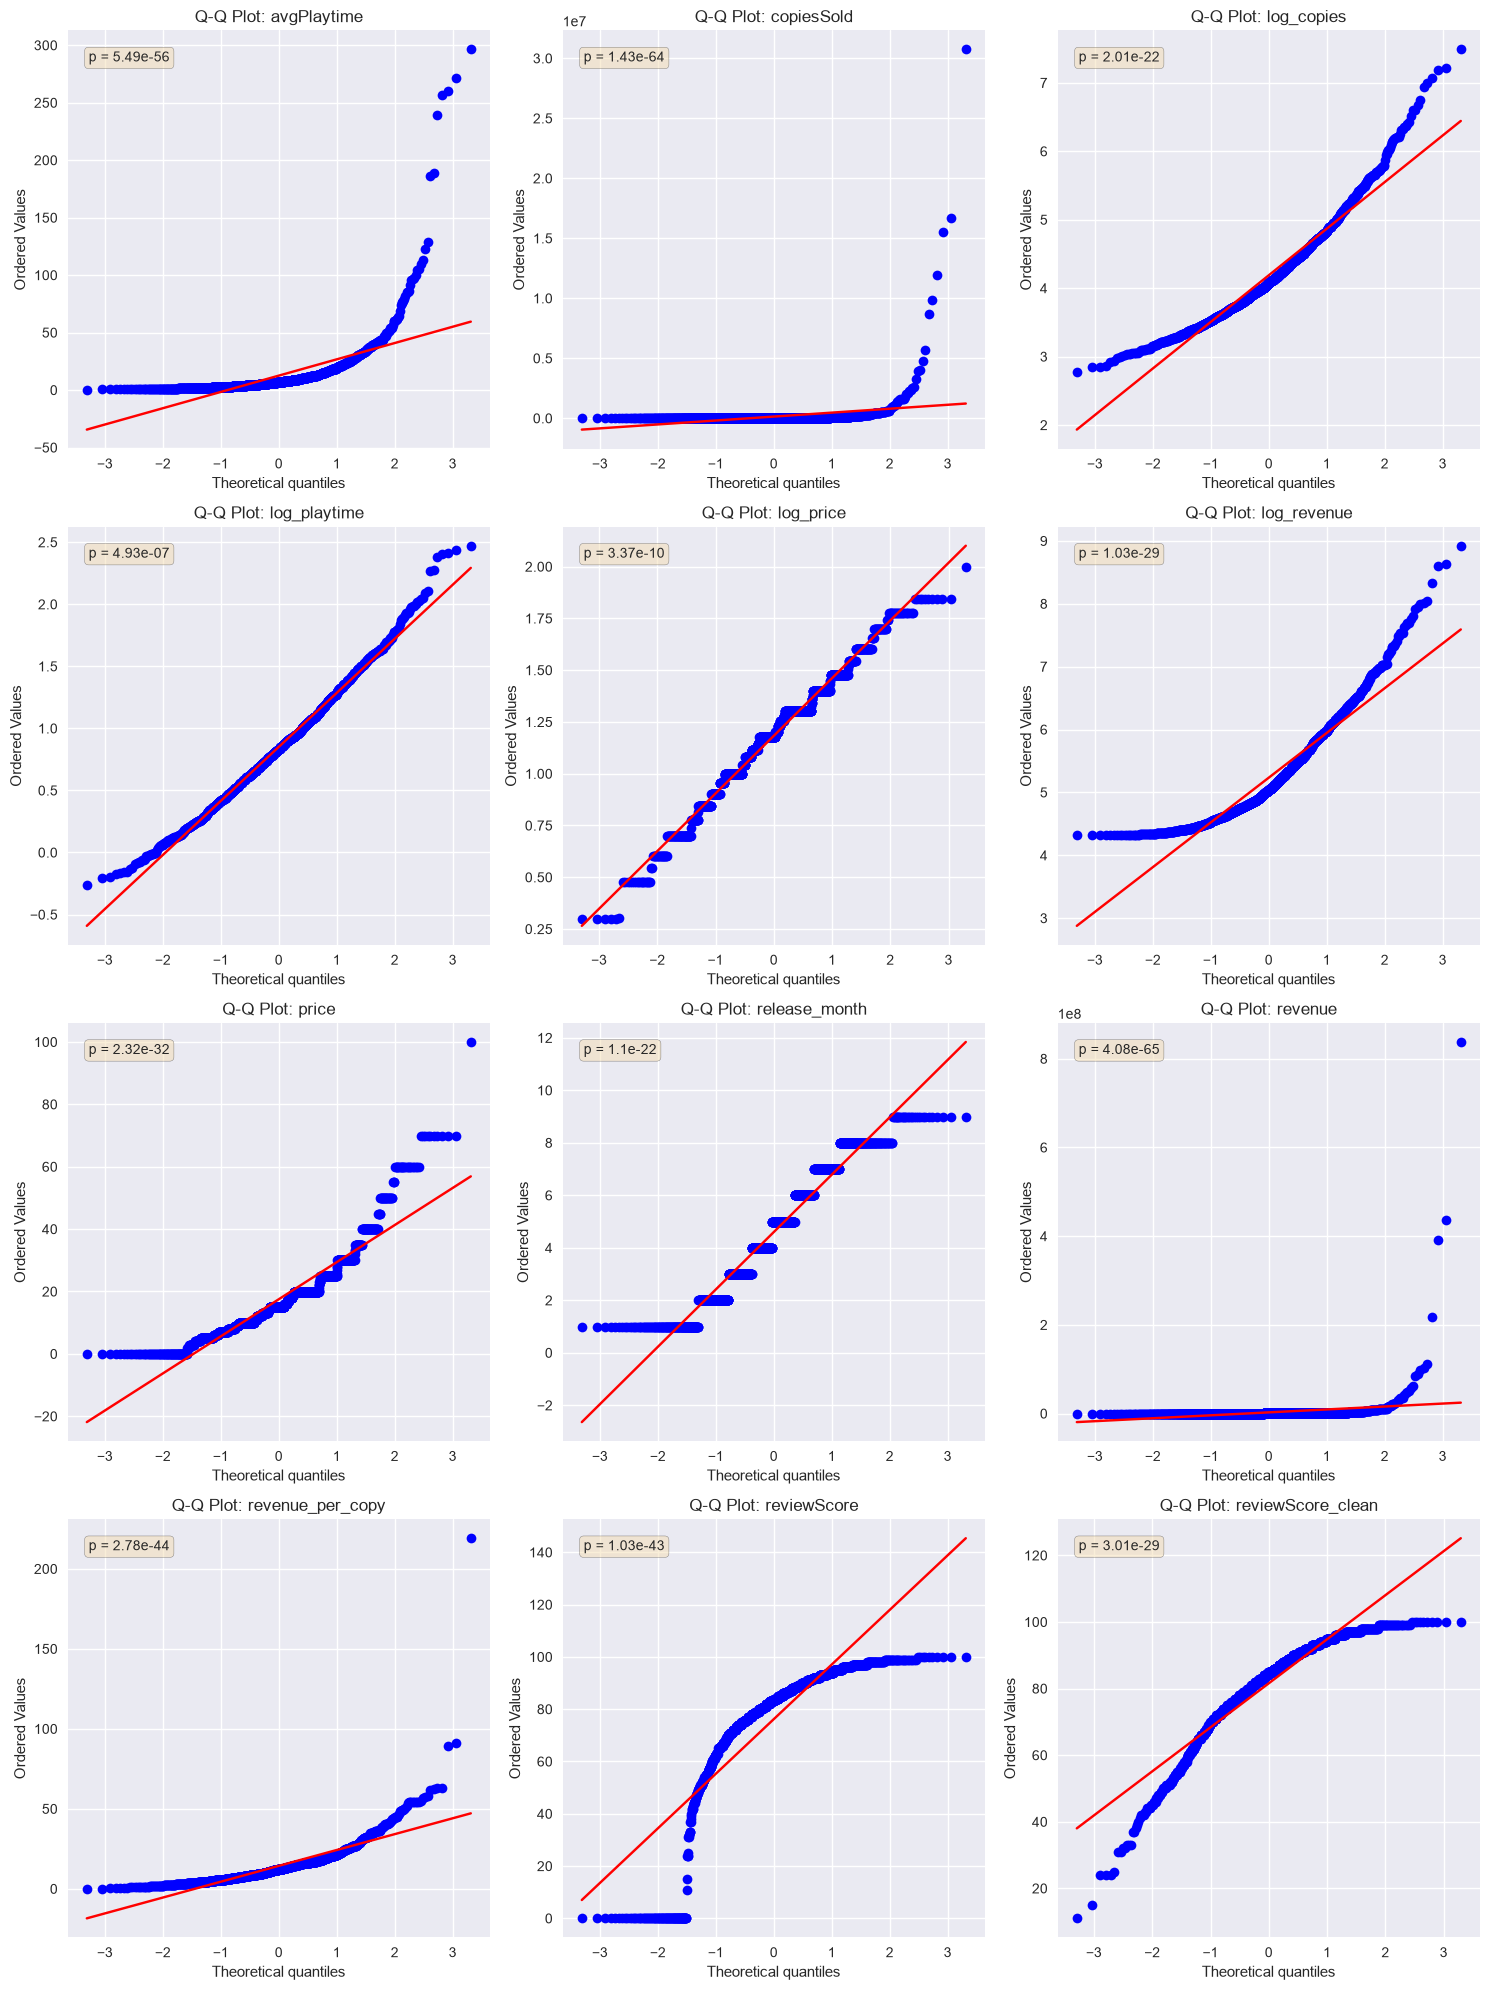

All visualizations created successfully!


In [12]:
create_qq_plots(df)

print("All visualizations created successfully!")
